In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv(r"D:\DSML\netflix-eda-project\data\netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Basic Dataset Exploration
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 824.8+ KB


,release_year
count,8797.000000
mean,2014.183472
std,8.822191
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 1. Content Type Analysis
## Question: Are movies or TV shows more common?

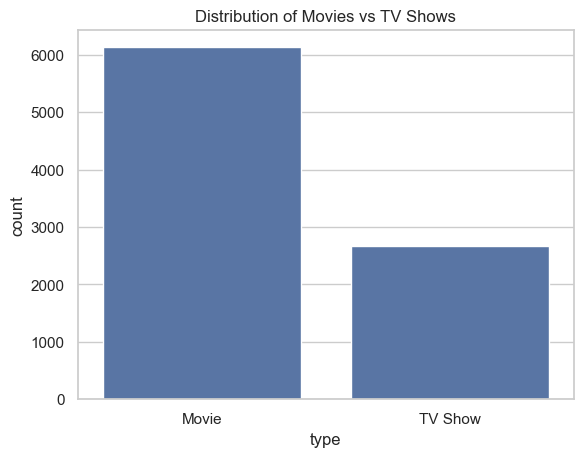

In [23]:
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.savefig("D:/DSML/netflix-eda-project/images/movies_vs_tvshows.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Movies dominate Netflix content compared to TV shows.

## 2. Content Release Over Time

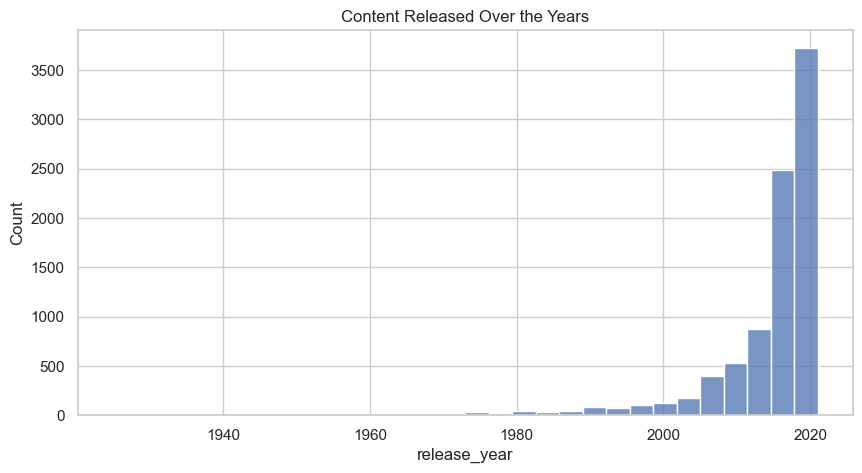

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title("Content Released Over the Years")
plt.savefig("D:/DSML/netflix-eda-project/images/release_year_trend.png",
            dpi=300, bbox_inches='tight')

plt.show()

## Insight: Content production increased significantly after 2015.

## 3. Top Countries Producing Content

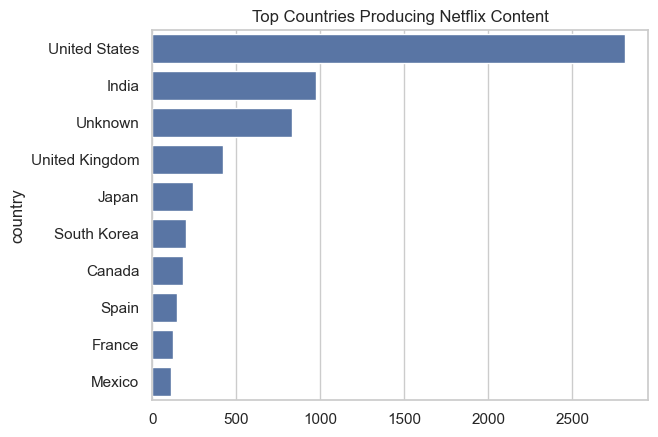

In [25]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries Producing Netflix Content")
plt.savefig("D:/DSML/netflix-eda-project/images/top_10_countries.png",
            dpi=300, bbox_inches='tight')

plt.show()

## Insight:
USA produces the highest number of Netflix titles.

## 4. Rating Distribution

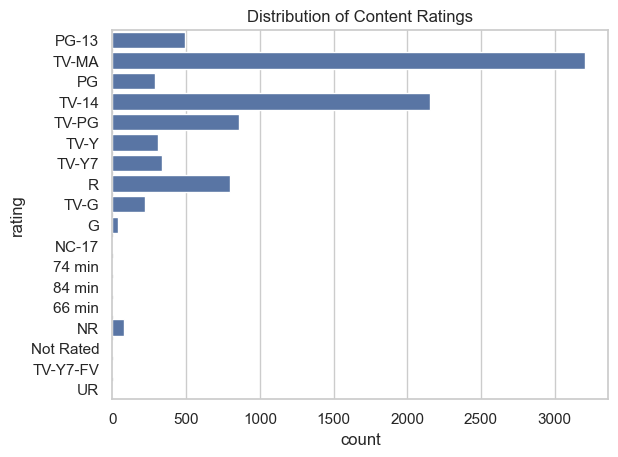

In [22]:
sns.countplot(y='rating', data=df)
plt.title("Distribution of Content Ratings")
plt.savefig("D:/DSML/netflix-eda-project/images/rating_distribution.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Insight:
TV-MA and TV-14 dominate Netflix content ratings.

## 5. Movie Duration Analysis

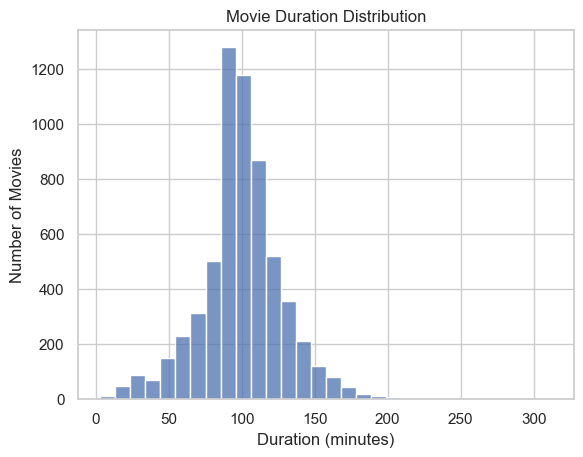

In [21]:
# Filter only movies
df_movies = df[df['type'] == "Movie"].copy()

# Remove ' min' text
df_movies['duration'] = df_movies['duration'].str.replace(' min', '', regex=False)

# Convert to numeric
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

# Plot histogram
sns.histplot(df_movies['duration'], bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.savefig("D:/DSML/netflix-eda-project/images/movie_duration_distribution.png",
            dpi=300, bbox_inches='tight')

plt.show()

## Insight:
Most Netflix movies are between 80–120 minutes.

## 6. Genre Analysis

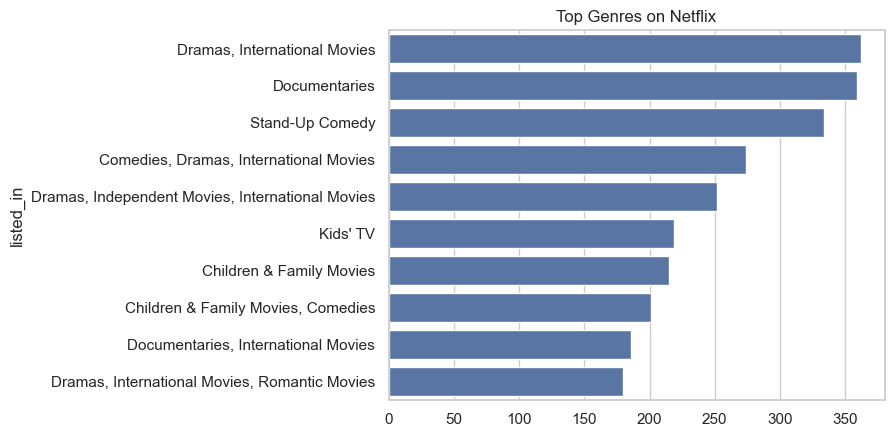

In [20]:
top_genres = df['listed_in'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres on Netflix")
plt.savefig("D:/DSML/netflix-eda-project/images/top_genres.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Key Insights

• Movies dominate Netflix content.

• Content production increased rapidly after 2015.

• USA produces the most Netflix titles.

• Most movies last between 80–120 minutes.

• TV-MA and TV-14 are the most common ratings.